In [1]:
"""
Copy-paste single-file script.

What this version adds vs your original:
1) Bulk WLS with *random absorption path length* (Beer–Lambert):
   - In any volume with wls=True and mu_a(λ)>0, we sample s_abs = -ln(U)/mu_a(λ)
   - If s_abs happens before the next boundary, we absorb there and (with QY) re-emit
2) Optional dichroic “mirror slab” behavior:
   - At interfaces into/out of the DM volume, apply wavelength-dependent reflect/transmit
   - Reflection is specular about the boundary normal; transmission continues forward
   - (You can switch this off by setting dm_is_dichroic=False)

Time-of-flight is intentionally omitted; compute later from the saved trajectory + n(λ).
"""

import numpy as np
import pandas as pd
import time
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm
import matplotlib.pyplot as plt


In [2]:
# -----------------------------
# Optics helpers
# -----------------------------

C0 = 299_792_458.0

def random_isotropic_direction(rng):
    u = rng.uniform(-1.0, 1.0)
    phi = rng.uniform(0.0, 2.0*np.pi)
    s = np.sqrt(max(0.0, 1.0 - u*u))
    return np.array([s*np.cos(phi), s*np.sin(phi), u], dtype=float)

def reflect(direction, normal):
    d = direction / np.linalg.norm(direction)
    n = normal / np.linalg.norm(normal)
    r = d - 2.0*np.dot(d, n)*n
    return r / np.linalg.norm(r)

def refract(direction, normal, n1, n2):
    d = direction / np.linalg.norm(direction)
    n = normal / np.linalg.norm(normal)

    cos_i = -np.dot(n, d)
    sin2_i = max(0.0, 1.0 - cos_i*cos_i)
    eta = n1 / n2
    sin2_t = eta*eta * sin2_i

    if sin2_t >= 1.0:
        return None  # TIR

    cos_t = np.sqrt(max(0.0, 1.0 - sin2_t))
    t = eta*d + (eta*cos_i - cos_t)*n
    return t / np.linalg.norm(t)

In [3]:
# -----------------------------
# Geometry: AABB cuboid
# -----------------------------

class Cuboid:
    """
    Axis-aligned cuboid. Optional physics:
      - wls: Beer–Lambert absorption in volume, with re-emission
      - mu_a: absorption coefficient [1/m] vs wavelength (dict/callable/scalar)
      - quantum_yield: re-emission probability after absorption
      - emission: either transitions dict (nearest key) or gaussian peak/sigma
      - is_dichroic: if True, apply reflectance/transmittance at interfaces
      - reflectance: dict/callable/scalar returning R(λ) in [0,1]
        (T is assumed 1-R; you can also set transmittance similarly if you want)
    """
    def __init__(
        self,
        vertices,
        refractive_index=None,
        name=None,
        wls=False,
        mu_a=0.0,
        quantum_yield=1.0,
        wls_transitions=None,
        emission_peak_nm=None,
        emission_sigma_nm=None,
        is_dichroic=False,
        reflectance=0.0,
    ):
        self.vertices = np.array(vertices, dtype=float)
        self.min_vertex = np.min(self.vertices, axis=0)
        self.max_vertex = np.max(self.vertices, axis=0)

        self.refractive_index = refractive_index if refractive_index is not None else {400.0: 1.0}
        self.name = name

        self.wls = bool(wls)
        self.mu_a = mu_a
        self.quantum_yield = float(quantum_yield)
        self.wls_transitions = wls_transitions or {}
        self.emission_peak_nm = emission_peak_nm
        self.emission_sigma_nm = emission_sigma_nm

        self.is_dichroic = bool(is_dichroic)
        self.reflectance = reflectance

    def contains(self, point, eps=1e-12):
        p = np.asarray(point, float)
        return np.all(p >= self.min_vertex - eps) and np.all(p <= self.max_vertex + eps)

    def intersect_distance(self, origin, direction):
        """
        Ray-AABB intersection distance to first hit (>=0). Returns inf if no hit.
        """
        o = np.asarray(origin, float)
        d = np.asarray(direction, float)

        inv = np.where(np.abs(d) > 0, 1.0 / d, np.inf)
        t0 = (self.min_vertex - o) * inv
        t1 = (self.max_vertex - o) * inv

        tmin = np.max(np.minimum(t0, t1))
        tmax = np.min(np.maximum(t0, t1))
        if tmax < 0 or tmin > tmax:
            return np.inf
        return tmin if tmin >= 0 else tmax

    def surface_normal_at(self, point, eps=1e-9):
        p = np.asarray(point, float)
        if abs(p[0] - self.min_vertex[0]) < eps: return np.array([-1.0, 0.0, 0.0])
        if abs(p[0] - self.max_vertex[0]) < eps: return np.array([+1.0, 0.0, 0.0])
        if abs(p[1] - self.min_vertex[1]) < eps: return np.array([0.0, -1.0, 0.0])
        if abs(p[1] - self.max_vertex[1]) < eps: return np.array([0.0, +1.0, 0.0])
        if abs(p[2] - self.min_vertex[2]) < eps: return np.array([0.0, 0.0, -1.0])
        if abs(p[2] - self.max_vertex[2]) < eps: return np.array([0.0, 0.0, +1.0])

        # fallback
        dmins = np.abs(p - self.min_vertex)
        dmaxs = np.abs(self.max_vertex - p)
        candidates = np.concatenate([dmins, dmaxs])
        k = int(np.argmin(candidates))
        return [
            np.array([-1.0,0,0]), np.array([0,-1.0,0]), np.array([0,0,-1.0]),
            np.array([+1.0,0,0]), np.array([0,+1.0,0]), np.array([0,0,+1.0]),
        ][k]

    def get_refractive_index(self, wavelength_nm):
        if isinstance(self.refractive_index, dict):
            keys = np.array(list(self.refractive_index.keys()), dtype=float)
            idx = int(np.abs(keys - wavelength_nm).argmin())
            return float(self.refractive_index[float(keys[idx])])
        if callable(self.refractive_index):
            return float(self.refractive_index(wavelength_nm))
        return float(self.refractive_index)

    def get_mu_a(self, wavelength_nm):
        if isinstance(self.mu_a, dict):
            keys = np.array(list(self.mu_a.keys()), dtype=float)
            idx = int(np.abs(keys - wavelength_nm).argmin())
            return float(self.mu_a[float(keys[idx])])
        if callable(self.mu_a):
            return float(self.mu_a(wavelength_nm))
        return float(self.mu_a)

    def get_reflectance(self, wavelength_nm):
        if isinstance(self.reflectance, dict):
            keys = np.array(list(self.reflectance.keys()), dtype=float)
            idx = int(np.abs(keys - wavelength_nm).argmin())
            return float(self.reflectance[float(keys[idx])])
        if callable(self.reflectance):
            return float(self.reflectance(wavelength_nm))
        return float(self.reflectance)

    def sample_emission_wavelength(self, rng, in_lambda_nm):
        # 1) transitions dict (nearest key)
        if self.wls_transitions:
            keys = np.array(list(self.wls_transitions.keys()), dtype=float)
            idx = int(np.abs(keys - in_lambda_nm).argmin())
            return float(self.wls_transitions[float(keys[idx])])
        # 2) gaussian peak/sigma
        if self.emission_peak_nm is not None:
            sigma = float(self.emission_sigma_nm) if self.emission_sigma_nm is not None else 10.0
            out = rng.normal(loc=float(self.emission_peak_nm), scale=sigma)
            return float(max(1.0, out))
        # 3) no shift
        return float(in_lambda_nm)

    def which_face(self, point, eps=1e-9):
        p = np.asarray(point, float)
        if abs(p[0] - self.min_vertex[0]) < eps: return "xmin"
        if abs(p[0] - self.max_vertex[0]) < eps: return "xmax"
        if abs(p[1] - self.min_vertex[1]) < eps: return "ymin"
        if abs(p[1] - self.max_vertex[1]) < eps: return "ymax"
        if abs(p[2] - self.min_vertex[2]) < eps: return "zmin"
        if abs(p[2] - self.max_vertex[2]) < eps: return "zmax"
        return None

In [4]:
# -----------------------------
# Simulation
# -----------------------------

class PhotonSimulation:
    def __init__(
        self,
        volumes=None,
        source_position=None,
        sensor_positions=None,
        sensor_radius=0.0,
        num_photons=1000,
        max_thrown=10000,
        max_workers=8,
        initial_wavelength_nm=128.0,
        max_steps=100000,
        rng_seed=None,
    ):
        self.volumes = volumes[:] if volumes else []
        self.source_position = np.array(source_position, dtype=float) if source_position is not None else None
        self.sensor_positions = np.array(sensor_positions, dtype=float) if sensor_positions is not None else None
        self.sensor_radius = float(sensor_radius)

        self.num_photons = int(num_photons)
        self.max_thrown = int(max_thrown)
        self.max_workers = int(max_workers)
        self.initial_wavelength_nm = float(initial_wavelength_nm)
        self.max_steps = int(max_steps)
        self.rng_seed = rng_seed

        self.data = []
        self.data_df = None

        if self.volumes:
            all_vertices = np.vstack([v.vertices for v in self.volumes])
            self.combined_region = Cuboid(all_vertices, name="combined")
        else:
            self.combined_region = None

    def find_containing_volume(self, point):
        for idx, v in enumerate(self.volumes):
            if v.contains(point):
                return idx, v
        return None, None

    def hits_any_sensor(self, point):
        if self.sensor_positions is None or len(self.sensor_positions) == 0:
            return False
        p = np.asarray(point, float)
        d = np.linalg.norm(self.sensor_positions - p[None, :], axis=1)
        return bool(np.any(d <= self.sensor_radius))

    def serialize_trajectory(self, trajectory):
        return ";".join([",".join(map(str, p)) for p in trajectory])

    def propagate_single_photon(self, photon_index=0):
        seed = None if self.rng_seed is None else (self.rng_seed + 1_000_003 * photon_index)
        rng = np.random.default_rng(seed)

        direction = random_isotropic_direction(rng)
        position = self.source_position.copy()

        wavelength = self.initial_wavelength_nm
        wavelength_history = [wavelength]

        trajectory = [position.tolist()]

        # --- Counters ---
        n_reflections = 0     # all reflections (includes TIR + "same-volume" + dichroic reflections)
        n_tir = 0             # subset of reflections caused by total internal reflection
        n_refractions = 0     # successful refractions (transmissions into a different volume)

        path_length = 0.0

        idx, current = self.find_containing_volume(position)
        if current is None:
            return trajectory, "lost_outside", n_reflections, n_tir, n_refractions, path_length, wavelength_history

        eps = 1e-9

        for _ in range(self.max_steps):
            if self.combined_region is not None and not self.combined_region.contains(position):
                return trajectory, f"lost_{current.name or idx}", n_reflections, n_tir, n_refractions, path_length, wavelength_history

            # distance to current boundary
            t_boundary = current.intersect_distance(position, direction)
            if not np.isfinite(t_boundary) or t_boundary == np.inf:
                return trajectory, f"lost_{current.name or idx}", n_reflections, n_tir, n_refractions, path_length, wavelength_history

            # ----- BULK WLS absorption competition -----
            # Sample absorption distance in current medium; if it happens before boundary,
            # absorb at that interior point and re-emit.
            if current.wls:
                mu = max(0.0, current.get_mu_a(wavelength))  # [1/m]
                if mu > 0.0:
                    U = max(rng.uniform(0.0, 1.0), 1e-300)
                    s_abs = -np.log(U) / mu

                    if s_abs < t_boundary:
                        # absorb in bulk before boundary
                        new_pos = position + direction * s_abs
                        trajectory.append(new_pos.tolist())
                        path_length += float(np.linalg.norm(new_pos - position))
                        position = new_pos

                        # non-radiative loss vs re-emission
                        if rng.uniform(0.0, 1.0) > current.quantum_yield:
                            return trajectory, f"absorbed_nonrad_{current.name or idx}", n_reflections, n_tir, n_refractions, path_length, wavelength_history

                        # re-emit
                        wavelength = current.sample_emission_wavelength(rng, wavelength)
                        wavelength_history.append(wavelength)
                        direction = random_isotropic_direction(rng)

                        # optional: immediate sensor hit (rare)
                        if self.hits_any_sensor(position):
                            return trajectory, "arrived", n_reflections, n_tir, n_refractions, path_length, wavelength_history

                        # stay in same volume after re-emission
                        continue

            # otherwise propagate to boundary
            boundary_pos = position + direction * t_boundary
            trajectory.append(boundary_pos.tolist())
            path_length += float(np.linalg.norm(boundary_pos - position))
            position = boundary_pos

            # sensor hit test at boundary point
            if self.hits_any_sensor(position):
                return trajectory, "arrived", n_reflections, n_tir, n_refractions, path_length, wavelength_history

            # Determine next volume by nudging forward
            ahead = position + direction * eps
            next_idx, next_vol = self.find_containing_volume(ahead)

            if next_vol is None:
                return trajectory, f"lost_{current.name or idx}", n_reflections, n_tir, n_refractions, path_length, wavelength_history

            n_face = current.surface_normal_at(position)
            if np.dot(direction, n_face) > 0:
                n_face = -n_face

            # ----- Dichroic behavior (optional) -----
            # If current or next volume is dichroic, apply wavelength-dependent reflectance at interface.
            if current.is_dichroic or next_vol.is_dichroic:
                # choose which reflectance curve to use (prefer the DM volume's setting)
                dm_vol = current if current.is_dichroic else next_vol
                R = np.clip(dm_vol.get_reflectance(wavelength), 0.0, 1.0)
                if rng.uniform(0.0, 1.0) < R:
                    direction = reflect(direction, n_face)
                    n_reflections += 1
                    position = position + direction * eps
                    continue
                # else transmit: fall through to refraction handling below

            # ----- Regular reflection (same-volume boundary) -----
            n1 = current.get_refractive_index(wavelength)
            n2 = next_vol.get_refractive_index(wavelength)

            # SAME OPTICAL MEDIUM → just step through
            if np.isclose(n1, n2, rtol=0, atol=1e-6):
                idx, current = next_idx, next_vol
                position = position + direction * eps
                continue

            # REAL OPTICAL INTERFACE BELOW THIS POINT
            if n1 > n2:
                cosi = -np.dot(n_face, direction)
                cosi = np.clip(cosi, -1.0, 1.0)
                sini2 = max(0.0, 1.0 - cosi*cosi)
                # TIR condition: (n1/n2)^2 * sin^2(theta_i) > 1
                if (n1/n2)**2 * sini2 > 1.0:
                    pass  # this is a true TIR candidate

            new_dir = refract(direction, n_face, n1, n2)
            if new_dir is None:
                # Total internal reflection
                direction = reflect(direction, n_face)
                n_reflections += 1
                n_tir += 1
                position = position + direction * eps
                continue

            # True refraction
            direction = new_dir
            n_refractions += 1
            idx, current = next_idx, next_vol
            position = position + direction * eps

            if new_dir is None:
                # Total internal reflection -> reflect
                direction = reflect(direction, n_face)
                n_reflections += 1
                n_tir += 1
                position = position + direction * eps
                continue

            # Successful refraction/transmission into next volume
            direction = new_dir
            n_refractions += 1
            idx, current = next_idx, next_vol
            position = position + direction * eps

        return trajectory, f"lost_maxsteps_{current.name or idx}", n_reflections, n_tir, n_refractions, path_length, wavelength_history

    def propagate_photons(self):
        start = time.time()
        self.data = []

        successful = 0
        thrown = 0

        with ThreadPoolExecutor(max_workers=self.max_workers) as executor:
            futures = {executor.submit(self.propagate_single_photon, i): i for i in range(self.max_thrown)}
            with tqdm(total=self.max_thrown, desc="Overall Progress", position=0, leave=True) as pbar:
                for fut in as_completed(futures):
                    thrown += 1
                    traj, status, n_refl, n_tir, n_refr, plen, wl_hist = fut.result()
                    pbar.update(1)

                    self.data.append({
                        "trajectory": self.serialize_trajectory(traj),
                        "event_type": status,
                        "arrived": status == "arrived",
                        "lost": status != "arrived",
                        "n_reflections": n_refl,
                        "n_tir": n_tir,
                        "n_refractions": n_refr,
                        "path_length": plen,
                        "wavelength_history": ";".join(map(lambda x: f"{x:.6g}", wl_hist)),
                    })

                    if status == "arrived":
                        successful += 1
                        if successful >= self.num_photons:
                            break

                    if thrown >= self.max_thrown:
                        break

        self.data_df = pd.DataFrame(self.data)
        elapsed = time.time() - start

        print(f"Total photons thrown: {thrown}")
        print(f"Successful photons: {int(self.data_df['arrived'].sum())}")
        print(f"Elapsed time: {elapsed:.3f} s")

        for v in self.volumes:
            name = v.name or self.volumes.index(v)
            key = f"lost_{name}"
            n_lost = int((self.data_df["event_type"] == key).sum())
            if n_lost:
                print(f"Lost in {name}: {n_lost}")



Note: you may need to restart the kernel to use updated packages.


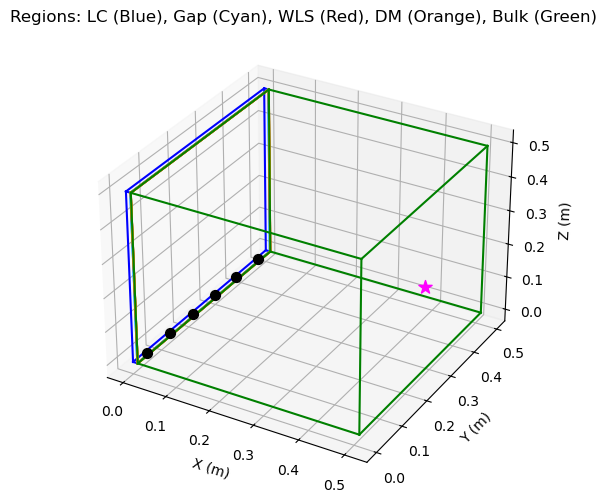

In [5]:
%pip install matplotlib numpy
import matplotlib.pyplot as plt
import numpy as np

# =========================================================
# YOUR SETUP (directly integrated)
# =========================================================

# define config inputs
width = 0.5  # meters
height = 0.5  # meters
# bulk
bulk_x = 0.5
bulk_y = height
bulk_z = width
# wls
wls_x = 3e-6
wls_y = height
wls_z = width
# dichroic mirror
dm_x = 112e-6
dm_y = height
dm_z = width
# gap
lar_gap_x = 1e-3
lar_gap_y = height
lar_gap_z = width
# lc
lc_x = 1e-2
lc_y = height
lc_z = width

# sensors
n_sipms = 6
sensor_positions = [[lc_x/2.0, (1 + 2 * i) / (2 * n_sipms) * height, 0.0] for i in range(n_sipms)]

# Light collection region (LC)
lc_region_vertices = [
    [0, 0, 0], [lc_x, 0, 0],
    [lc_x, lc_y, 0], [0, lc_y, 0],
    [0, 0, lc_z], [lc_x, 0, lc_z],
    [lc_x, lc_y, lc_z], [0, lc_y, lc_z]
]

# liquid argon gap between LC and WLS
# Define starting x coordinate for each region stepwise
x_coord_sum = 0

# LC region already defined above, so start after LC
x_coord_sum += lc_x

# LAr gap region
lar_gap_vertices = [
    [x_coord_sum, 0, 0], [x_coord_sum + lar_gap_x, 0, 0], [x_coord_sum + lar_gap_x, lar_gap_y, 0], [x_coord_sum, lar_gap_y, 0],
    [x_coord_sum, 0, lar_gap_z], [x_coord_sum + lar_gap_x, 0, lar_gap_z], [x_coord_sum + lar_gap_x, lar_gap_y, lar_gap_z], [x_coord_sum, lar_gap_y, lar_gap_z]
]
x_coord_sum += lar_gap_x

# Wavelength shifter region (WLS), sits after LAr gap
wls_region_vertices = [
    [x_coord_sum, 0, 0], [x_coord_sum + wls_x, 0, 0], [x_coord_sum + wls_x, wls_y, 0], [x_coord_sum, wls_y, 0],
    [x_coord_sum, 0, wls_z], [x_coord_sum + wls_x, 0, wls_z], [x_coord_sum + wls_x, wls_y, wls_z], [x_coord_sum, wls_y, wls_z]
]
x_coord_sum += wls_x

# Dichroic mirror region (DM), sits after WLS
dm_region_vertices = [
    [x_coord_sum, 0, 0], [x_coord_sum + dm_x, 0, 0], [x_coord_sum + dm_x, dm_y, 0], [x_coord_sum, dm_y, 0],
    [x_coord_sum, 0, dm_z], [x_coord_sum + dm_x, 0, dm_z], [x_coord_sum + dm_x, dm_y, dm_z], [x_coord_sum, dm_y, dm_z]
]
x_coord_sum += dm_x

# Bulk region, sits after DM
bulk_region_vertices = [
    [x_coord_sum, 0, 0], [x_coord_sum + bulk_x, 0, 0], [x_coord_sum + bulk_x, bulk_y, 0], [x_coord_sum, bulk_y, 0],
    [x_coord_sum, 0, bulk_z], [x_coord_sum + bulk_x, 0, bulk_z], [x_coord_sum + bulk_x, bulk_y, bulk_z], [x_coord_sum, bulk_y, bulk_z]
]

# source position at far end of bulk
source_position = [x_coord_sum + bulk_x, bulk_y / 2.0, bulk_z / 2.0]

# Visualisation of the regions
plt.figure(figsize=(8, 6))
ax = plt.axes(projection='3d')
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')

def draw_box(vertices, color):
    V = np.array(vertices, dtype=float)
    edges = [
        (0,1),(1,2),(2,3),(3,0),
        (4,5),(5,6),(6,7),(7,4),
        (0,4),(1,5),(2,6),(3,7)
    ]
    for a,b in edges:
        ax.plot([V[a,0],V[b,0]],[V[a,1],V[b,1]],[V[a,2],V[b,2]], color=color)

draw_box(lc_region_vertices, "blue")
draw_box(lar_gap_vertices, "cyan")
draw_box(wls_region_vertices, "red")
draw_box(dm_region_vertices, "orange")
draw_box(bulk_region_vertices, "green")

# sensors
for sp in sensor_positions:
    ax.scatter(sp[0], sp[1], sp[2], color="black", s=50)
# source
ax.scatter(source_position[0], source_position[1], source_position[2], color="magenta", s=100, marker='*')


ax.set_title("Regions: LC (Blue), Gap (Cyan), WLS (Red), DM (Orange), Bulk (Green)")
plt.show()

In [6]:
# =========================================================
# Physics knobs (EDIT THESE!)
# =========================================================

# --- EJ280 (LC) absorption coefficient mu_a [1/m] vs wavelength.
# You *must* tune these. If you set mu_a too small, almost no absorption->reemission.
# If too big, everything shifts immediately.
mu_a_lc = {
    128.0: 0.0,     # EJ280 typically not absorbing VUV if it doesn't see it; set as you like
    420.0: 20.0,    # example: absorption length 5 cm
    490.0: 0.2,     # example: mostly transparent at its own emission
}

# EJ280 emission ~490 nm (example)
lc_qy = 0.95

# --- TPB (WLS slab) absorption coefficient mu_a [1/m] vs wavelength.
# For a 3 µm film, mu_a can be enormous in VUV; treat these as placeholders.
mu_a_tpb = {
    128.0: 5e5,     # example: absorption length 2 microns
    420.0: 10.0,    # TPB mostly transparent in blue
    490.0: 1.0,
}
tpb_qy = 0.9

# --- Dichroic: reflectance vs wavelength (placeholders).
# For example: reflect blue (420) strongly, transmit green (490) mostly.
# You can invert this depending on your design.
dm_is_dichroic = True
dm_reflectance = {
    128.0: 0.2,
    420.0: 0.95,
    490.0: 0.10,
}

In [7]:
# =========================================================
# Define volumes (as Cuboid objects)
# =========================================================

lc = Cuboid(
    vertices=lc_region_vertices,
    refractive_index={128: 1.65, 420: 1.60, 490: 1.58},
    name="lc",
    wls=True,                          # EJ280 as bulk WLS
    mu_a=mu_a_lc,
    quantum_yield=lc_qy,
    emission_peak_nm=490.0,
    emission_sigma_nm=20.0,
)
lc.boundary_mode = {
    "ymin": "reflect",
    "ymax": "reflect",
    "zmin": "reflect",
    "zmax": "reflect",
    "xmin": "reflect",   # sensor side maybe?
    "xmax": "escape",
}
lc.reflectivity = {
    "ymin": 0.98,
    "ymax": 0.98,
    "zmin": 0.98,
    "zmax": 0.98,
    "xmin": 0.98,
}

lar_gap = Cuboid(
    vertices=lar_gap_vertices,
    refractive_index={128: 1.6, 420: 1.23, 490: 1.22},
    name="lar_gap",
    wls=False,
)
lar_gap.boundary_mode = {
    "ymin": "escape",
    "ymax": "escape",
    "zmin": "escape",
    "zmax": "escape",
    "xmin": "escape",   # sensor side maybe?
    "xmax": "escape",
}

wls = Cuboid(
    vertices=wls_region_vertices,
    refractive_index={128: 1.70, 420: 1.62, 490: 1.60},
    name="wls",
    wls=True,                          # TPB slab as bulk WLS
    mu_a=mu_a_tpb,
    quantum_yield=tpb_qy,
    emission_peak_nm=420.0,
    emission_sigma_nm=15.0,
)
wls.boundary_mode = {
    "ymin": "escape",
    "ymax": "escape",
    "zmin": "escape",
    "zmax": "escape",
    "xmin": "escape",   # sensor side maybe?
    "xmax": "escape",
}

dm = Cuboid(
    vertices=dm_region_vertices,
    refractive_index={128: 1.5, 420: 1.65, 490: 1.9},
    name="dm",
    wls=False,
    is_dichroic=dm_is_dichroic,
    reflectance=dm_reflectance,
)
dm.boundary_mode = {
    "ymin": "escape",
    "ymax": "escape",
    "zmin": "escape",
    "zmax": "escape",
    "xmin": "escape",   # sensor side maybe?
    "xmax": "escape",
}

bulk = Cuboid(
    vertices=bulk_region_vertices,
    refractive_index={128: 1.6, 420: 1.23, 490: 1.22},
    name="bulk",
    wls=False,
)
bulk.boundary_mode = {
    "ymin": "escape",
    "ymax": "escape",
    "zmin": "escape",
    "zmax": "escape",
    "xmin": "escape",   # sensor side maybe?
    "xmax": "escape",
}

volumes = [lc, lar_gap, wls, dm, bulk]

In [8]:
# =========================================================
# Run simulation
# =========================================================

simulation = PhotonSimulation(
    volumes=volumes,
    source_position=source_position,
    sensor_positions=sensor_positions,
    sensor_radius=0.01,
    num_photons=10000,
    max_thrown=100000,
    max_workers=8,
    initial_wavelength_nm=128.0,   # LAr scintillation example
    max_steps=5000,
    rng_seed=12345,
)

simulation.propagate_photons()

# DataFrame available as:
df = simulation.data_df
print(df.head())

Overall Progress: 100%|██████████| 100000/100000 [09:31<00:00, 174.92it/s]


Total photons thrown: 100000
Successful photons: 124
Elapsed time: 576.897 s
Lost in lc: 2025
Lost in lar_gap: 4
Lost in wls: 88
Lost in dm: 1620
Lost in bulk: 95686
                                          trajectory event_type  arrived  \
0  0.511115,0.25,0.25;0.511115,0.25,0.25;0.372060...  lost_bulk    False   
1              0.511115,0.25,0.25;0.511115,0.25,0.25  lost_bulk    False   
2  0.511115,0.25,0.25;0.511115,0.25,0.25;0.355938...  lost_bulk    False   
3  0.511115,0.25,0.25;0.511115,0.25,0.25;0.033431...  lost_bulk    False   
4              0.511115,0.25,0.25;0.511115,0.25,0.25  lost_bulk    False   

   lost  n_reflections  n_tir  n_refractions  path_length wavelength_history  
0  True              0      0              0     0.358411                128  
1  True              0      0              0     0.000000                128  
2  True              0      0              0     0.299754                128  
3  True              0      0              0     0.584968    

/var/folders/rc/blk_p25x629bs2hm6s03qd7r0000gp/T/ipykernel_68879/3476488356.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(event_types))


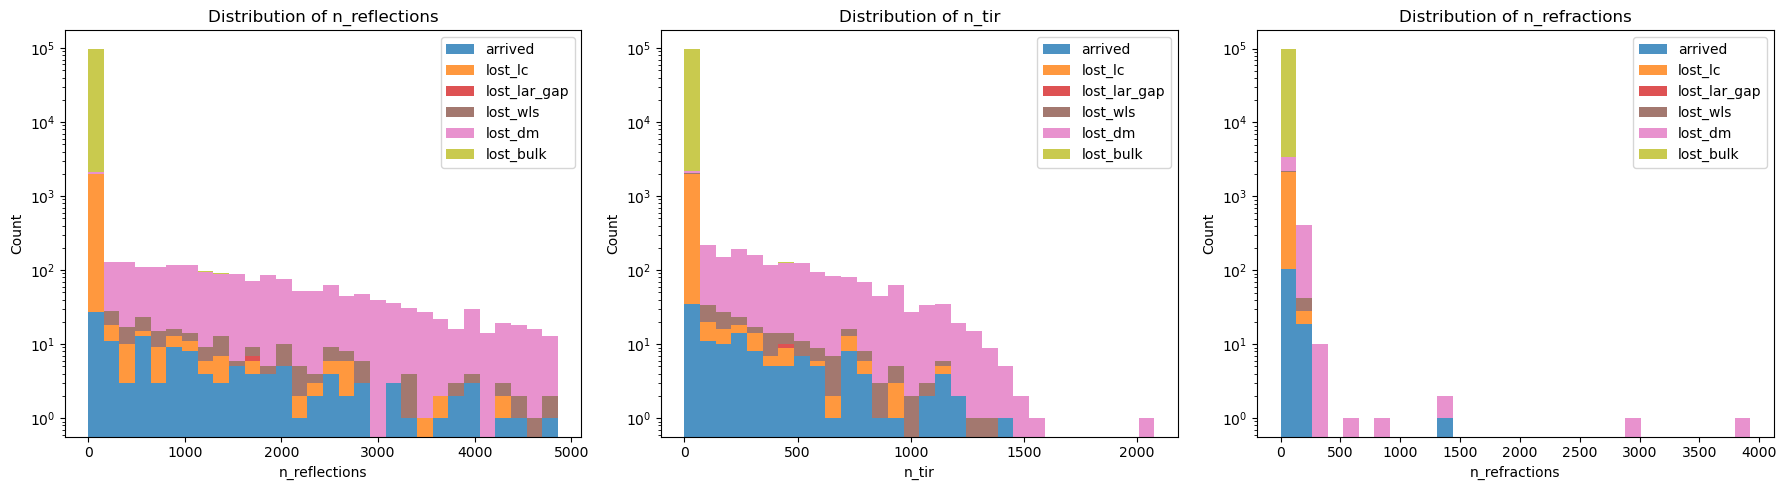

                    n_reflections                           n_tir              \
                             mean          std   max         mean         std   
event_type                                                                      
absorbed_nonrad_lc     157.636364   520.830927  1728    40.090909  132.966503   
absorbed_nonrad_wls     55.796460   322.275898  3930    16.100295   88.720267   
arrived               1218.500000  1202.058259  4739   336.935484  340.242041   
lost_bulk                0.056999     6.107223  1357     0.009845    1.978873   
lost_dm               1623.433333  1172.429366  4862   443.591358  329.629007   
lost_lar_gap           442.250000   883.167170  1767   113.500000  227.000000   
lost_lc                 30.229136   244.534889  4324     8.626667   69.398103   
lost_maxsteps_dm      4763.327586   471.837185  4895  1393.913793  247.199421   
lost_maxsteps_wls     4697.355556   572.449051  4891  1422.800000  293.252032   
lost_wls              1309.9

In [9]:
# Stacked histograms of n_reflections, n_tir, n_refractions for each event type
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
metrics = ['n_reflections', 'n_tir', 'n_refractions']
event_types = ['arrived', 'lost_lc', 'lost_lar_gap', 'lost_wls', 'lost_dm', 'lost_bulk', 'lost_maxsteps_bulk']
colors = plt.cm.get_cmap('tab10', len(event_types))

for i, metric in enumerate(metrics):
    ax = axs[i]
    data = [df[df['event_type'] == et][metric] for et in event_types if not df[df['event_type'] == et].empty]
    labels = [et for et in event_types if not df[df['event_type'] == et].empty]
    color_list = [colors(j) for j in range(len(labels))]
    ax.hist(data, bins=30, stacked=True, label=labels, color=color_list, alpha=0.8)
    ax.set_title(f'Distribution of {metric}')
    ax.set_xlabel(metric)
    ax.set_ylabel('Count')
    ax.set_yscale('log')
    ax.legend()
plt.tight_layout()
plt.show()

# print a table of n_reflections, n_tir, n_refractions statistics, by event type
stats = df.groupby('event_type').agg({
    'n_reflections': ['mean', 'std', 'max'],
    'n_tir': ['mean', 'std', 'max'],
    'n_refractions': ['mean', 'std', 'max'],
})
print(stats)

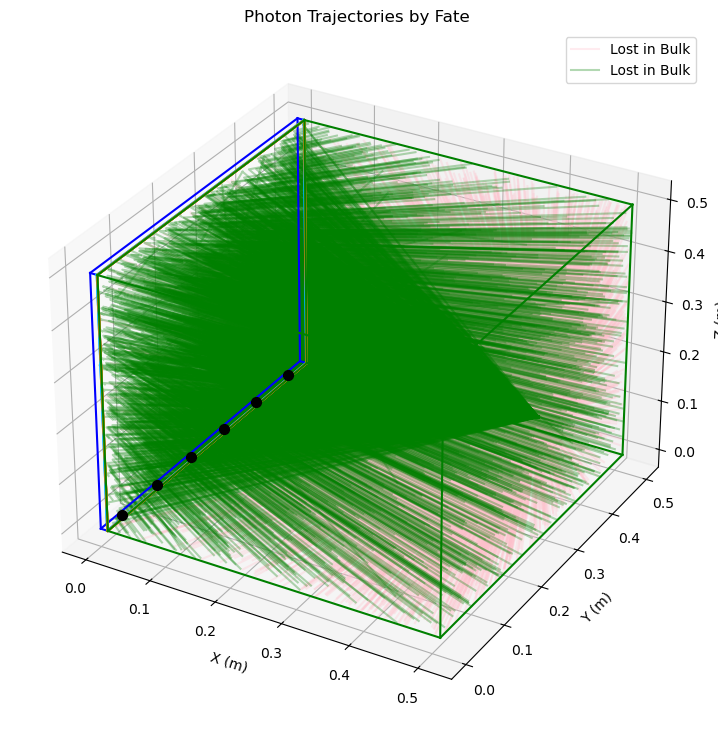

In [10]:
# Plot trajectories by event type: lost_bulk, lost_dm, lost_wls, lost_lc, arrived

plt.figure(figsize=(12, 9))
ax = plt.axes(projection='3d')
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')

# Helper for plotting
def plot_trajectories(df_subset, color, label, alpha=0.3, max_lines=10000):
    for i, traj_str in enumerate(df_subset['trajectory']):
        if i >= max_lines:
            break
        points = np.array([list(map(float, p.split(','))) for p in traj_str.split(';')], dtype=float)
        ax.plot(points[:,0], points[:,1], points[:,2], color=color, alpha=alpha, label=label if i == 0 else None)

# Plot each event type
plot_trajectories(df[(df['event_type'] == 'lost_bulk') & (df['n_reflections'] == 0)], 'pink', 'Lost in Bulk')
# plot only lost in bulk with at least one reflection
plot_trajectories(df[(df['event_type'] == 'lost_bulk') & (df['n_reflections'] > 0)], 'green', 'Lost in Bulk')

# Draw geometry
draw_box(lc_region_vertices, "blue")
draw_box(lar_gap_vertices, "cyan")
draw_box(wls_region_vertices, "red")
draw_box(dm_region_vertices, "orange")
draw_box(bulk_region_vertices, "green")

for sp in sensor_positions:
    ax.scatter(sp[0], sp[1], sp[2], color="black", s=50)

ax.set_title('Photon Trajectories by Fate')
ax.legend()
plt.show()

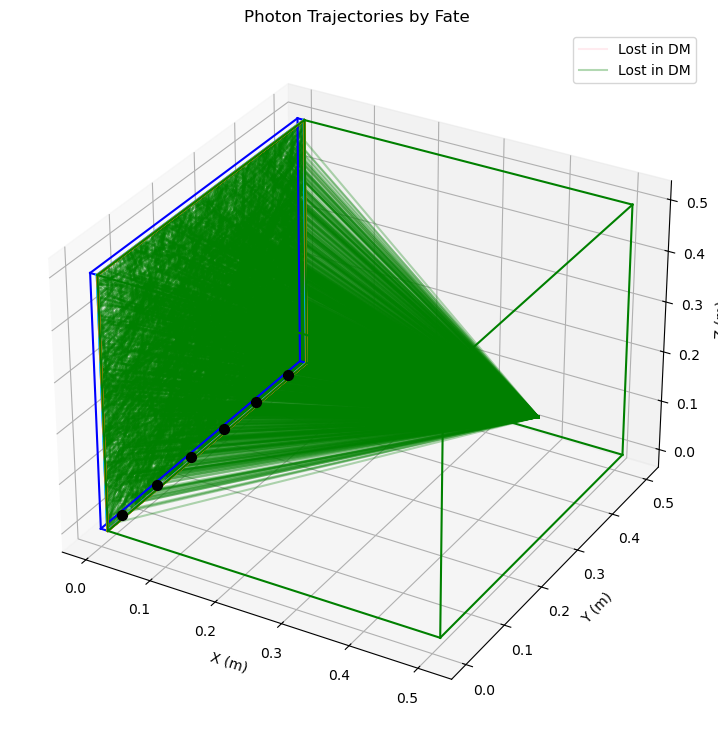

In [11]:
# Plot trajectories by event type: lost_bulk, lost_dm, lost_wls, lost_lc, arrived

plt.figure(figsize=(12, 9))
ax = plt.axes(projection='3d')
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')

# Helper for plotting
def plot_trajectories(df_subset, color, label, alpha=0.3, max_lines=10000):
    for i, traj_str in enumerate(df_subset['trajectory']):
        if i >= max_lines:
            break
        points = np.array([list(map(float, p.split(','))) for p in traj_str.split(';')], dtype=float)
        ax.plot(points[:,0], points[:,1], points[:,2], color=color, alpha=alpha, label=label if i == 0 else None)

# Plot each event type
plot_trajectories(df[(df['event_type'] == 'lost_dm') & (df['n_reflections'] == 0)], 'pink', 'Lost in DM')
# plot only lost in bulk with at least one reflection
plot_trajectories(df[(df['event_type'] == 'lost_dm') & (df['n_reflections'] > 0)], 'green', 'Lost in DM')

# Draw geometry
draw_box(lc_region_vertices, "blue")
draw_box(lar_gap_vertices, "cyan")
draw_box(wls_region_vertices, "red")
draw_box(dm_region_vertices, "orange")
draw_box(bulk_region_vertices, "green")

for sp in sensor_positions:
    ax.scatter(sp[0], sp[1], sp[2], color="black", s=50)

ax.set_title('Photon Trajectories by Fate')
ax.legend()
plt.show()

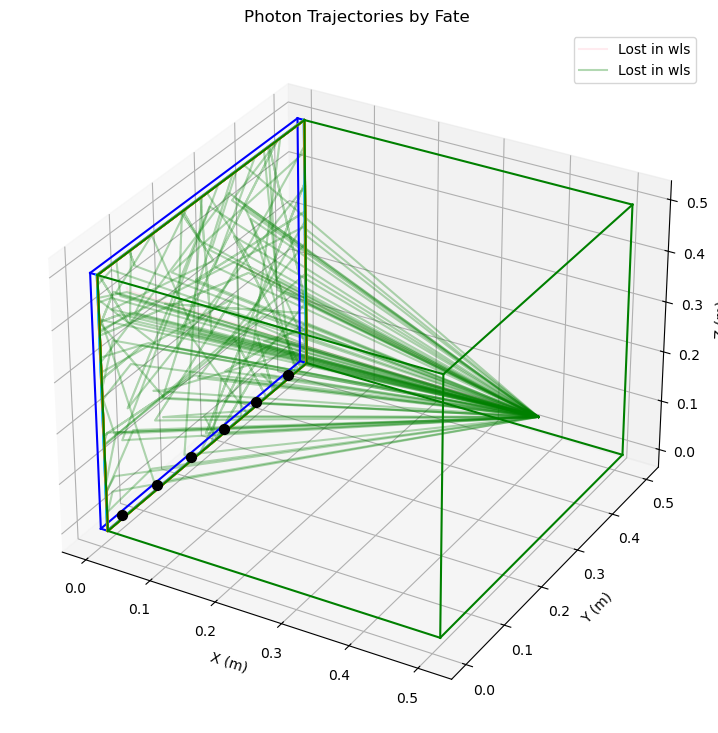

In [12]:
# Plot trajectories by event type: lost_bulk, lost_dm, lost_wls, lost_lc, arrived

plt.figure(figsize=(12, 9))
ax = plt.axes(projection='3d')
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')

# Helper for plotting
def plot_trajectories(df_subset, color, label, alpha=0.3, max_lines=10000):
    for i, traj_str in enumerate(df_subset['trajectory']):
        if i >= max_lines:
            break
        points = np.array([list(map(float, p.split(','))) for p in traj_str.split(';')], dtype=float)
        ax.plot(points[:,0], points[:,1], points[:,2], color=color, alpha=alpha, label=label if i == 0 else None)

# Plot each event type
plot_trajectories(df[(df['event_type'] == 'lost_wls') & (df['n_reflections'] == 0)], 'pink', 'Lost in wls')
# plot only lost in bulk with at least one reflection
plot_trajectories(df[(df['event_type'] == 'lost_wls') & (df['n_reflections'] > 0)], 'green', 'Lost in wls')

# Draw geometry
draw_box(lc_region_vertices, "blue")
draw_box(lar_gap_vertices, "cyan")
draw_box(wls_region_vertices, "red")
draw_box(dm_region_vertices, "orange")
draw_box(bulk_region_vertices, "green")

for sp in sensor_positions:
    ax.scatter(sp[0], sp[1], sp[2], color="black", s=50)

ax.set_title('Photon Trajectories by Fate')
ax.legend()
plt.show()

/var/folders/rc/blk_p25x629bs2hm6s03qd7r0000gp/T/ipykernel_68879/4058158908.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


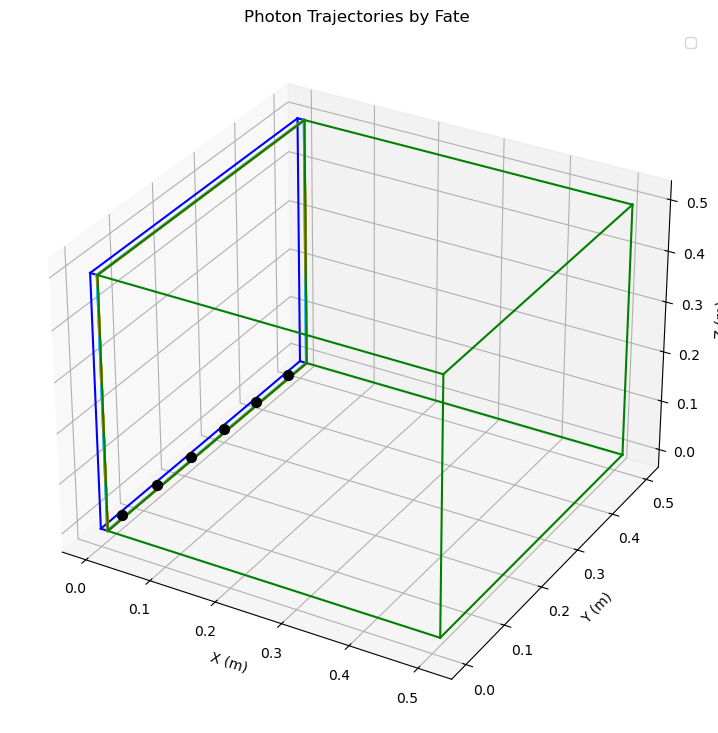

In [13]:
# Plot trajectories by event type: lost_bulk, lost_dm, lost_wls, lost_lc, arrived

plt.figure(figsize=(12, 9))
ax = plt.axes(projection='3d')
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')

# Helper for plotting
def plot_trajectories(df_subset, color, label, alpha=0.3, max_lines=10000):
    for i, traj_str in enumerate(df_subset['trajectory']):
        if i >= max_lines:
            break
        points = np.array([list(map(float, p.split(','))) for p in traj_str.split(';')], dtype=float)
        ax.plot(points[:,0], points[:,1], points[:,2], color=color, alpha=alpha, label=label if i == 0 else None)

# Plot each event type
plot_trajectories(df[(df['event_type'] == 'lost_gap') & (df['n_reflections'] == 0)], 'pink', 'Lost in gap')
# plot only lost in bulk with at least one reflection
plot_trajectories(df[(df['event_type'] == 'lost_gap') & (df['n_reflections'] > 0)], 'green', 'Lost in gap')

# Draw geometry
draw_box(lc_region_vertices, "blue")
draw_box(lar_gap_vertices, "cyan")
draw_box(wls_region_vertices, "red")
draw_box(dm_region_vertices, "orange")
draw_box(bulk_region_vertices, "green")

for sp in sensor_positions:
    ax.scatter(sp[0], sp[1], sp[2], color="black", s=50)

ax.set_title('Photon Trajectories by Fate')
ax.legend()
plt.show()

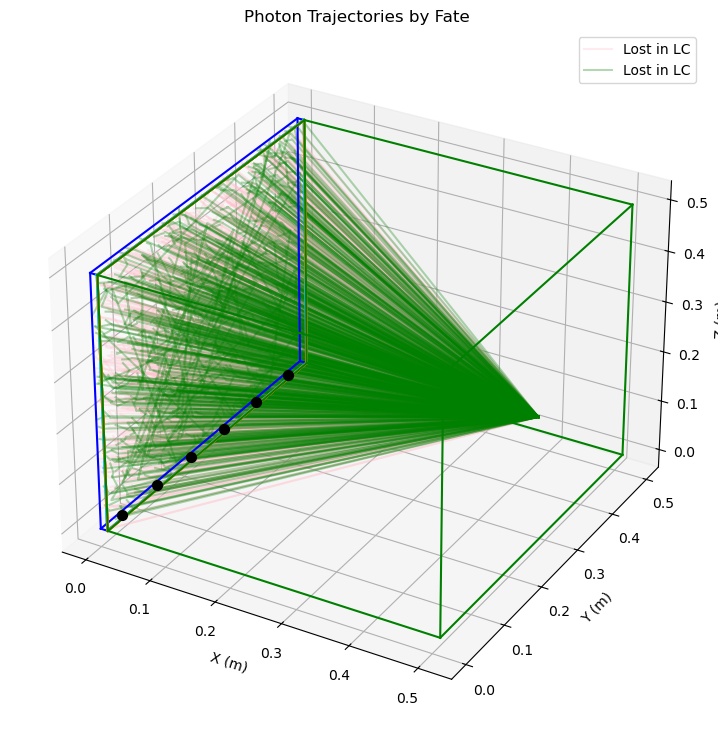

In [14]:
# Plot trajectories by event type: lost_bulk, lost_dm, lost_wls, lost_lc, arrived

plt.figure(figsize=(12, 9))
ax = plt.axes(projection='3d')
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')

# Helper for plotting
def plot_trajectories(df_subset, color, label, alpha=0.3, max_lines=10000):
    for i, traj_str in enumerate(df_subset['trajectory']):
        if i >= max_lines:
            break
        points = np.array([list(map(float, p.split(','))) for p in traj_str.split(';')], dtype=float)
        ax.plot(points[:,0], points[:,1], points[:,2], color=color, alpha=alpha, label=label if i == 0 else None)

# Plot each event type
plot_trajectories(df[(df['event_type'] == 'lost_lc') & (df['n_reflections'] == 0)], 'pink', 'Lost in LC')
# plot only lost in bulk with at least one reflection
plot_trajectories(df[(df['event_type'] == 'lost_lc') & (df['n_reflections'] > 0)], 'green', 'Lost in LC')

# Draw geometry
draw_box(lc_region_vertices, "blue")
draw_box(lar_gap_vertices, "cyan")
draw_box(wls_region_vertices, "red")
draw_box(dm_region_vertices, "orange")
draw_box(bulk_region_vertices, "green")

for sp in sensor_positions:
    ax.scatter(sp[0], sp[1], sp[2], color="black", s=50)

ax.set_title('Photon Trajectories by Fate')
ax.legend()
plt.show()

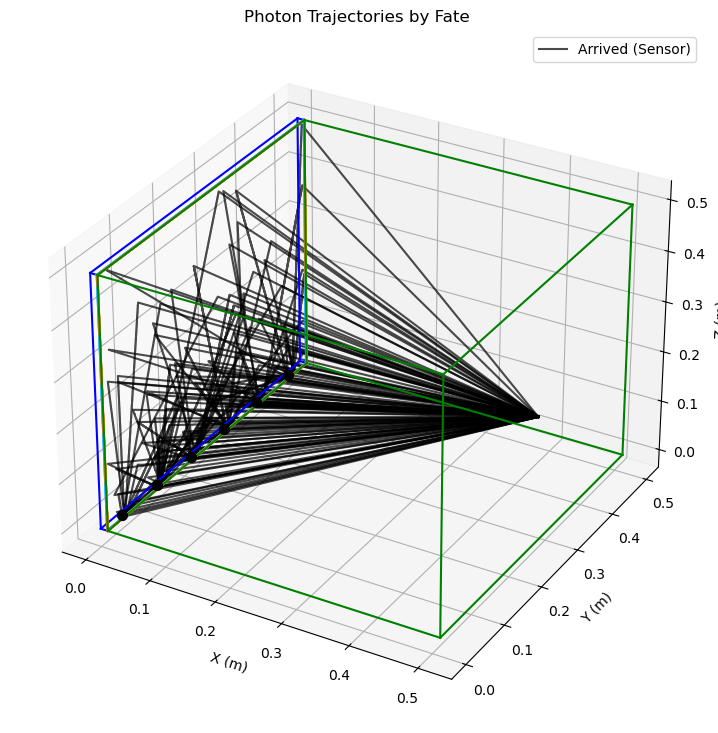

In [15]:
# Plot trajectories by event type: lost_bulk, lost_dm, lost_wls, lost_lc, arrived

plt.figure(figsize=(12, 9))
ax = plt.axes(projection='3d')
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')

# Helper for plotting
def plot_trajectories(df_subset, color, label, alpha=0.3, max_lines=10000):
    for i, traj_str in enumerate(df_subset['trajectory']):
        if i >= max_lines:
            break
        points = np.array([list(map(float, p.split(','))) for p in traj_str.split(';')], dtype=float)
        ax.plot(points[:,0], points[:,1], points[:,2], color=color, alpha=alpha, label=label if i == 0 else None)

# Plot each event type
plot_trajectories(df[df['event_type'] == 'arrived'], 'k', 'Arrived (Sensor)', alpha=0.7)
#plot_trajectories(df[df['event_type'] == 'lost_maxsteps_bulk'], 'magenta', 'Absorbed Non-Rad in LC', alpha=0.5)

# Draw geometry
draw_box(lc_region_vertices, "blue")
draw_box(lar_gap_vertices, "cyan")
draw_box(wls_region_vertices, "red")
draw_box(dm_region_vertices, "orange")
draw_box(bulk_region_vertices, "green")

for sp in sensor_positions:
    ax.scatter(sp[0], sp[1], sp[2], color="black", s=50)

ax.set_title('Photon Trajectories by Fate')
ax.legend()
plt.show()

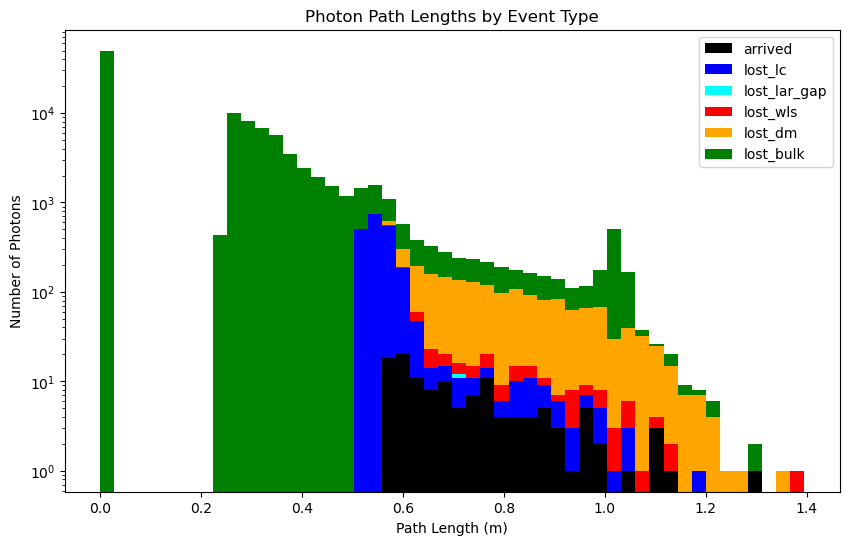

In [16]:
# stacked histgram of pathlengths by event type
plt.figure(figsize=(10, 6))
event_types = ['arrived', 'lost_lc', 'lost_lar_gap', 'lost_wls', 'lost_dm', 'lost_bulk']
colors = ['k', 'blue', 'cyan', 'red', 'orange', 'green']
plt.hist(
    [simulation.data_df[simulation.data_df['event_type'] == et]['path_length'] for et in event_types],
    bins=50,
    stacked=True,
    color=colors,
    label=event_types,
)
plt.xlabel('Path Length (m)')
plt.ylabel('Number of Photons')
plt.yscale('log')
plt.title('Photon Path Lengths by Event Type')
plt.legend()
plt.show()

In [17]:
# -----------------------------
# 1) Overall detection efficiency
# -----------------------------
n_arrived = int(simulation.data_df["arrived"].sum())
efficiency = (n_arrived / simulation.num_photons) * 100.0
print(f"Overall detection efficiency: {efficiency:.2f}% ({n_arrived} / {simulation.num_photons})")


# -----------------------------
# 2) Robust geometry (min-x face) + exact solid angle
# -----------------------------
verts = np.asarray(dm_region_vertices, dtype=float)     # shape (8, 3) expected
src   = np.asarray(source_position, dtype=float)        # shape (3,)

x_min, x_max = verts[:, 0].min(), verts[:, 0].max()
y_min, y_max = verts[:, 1].min(), verts[:, 1].max()
z_min, z_max = verts[:, 2].min(), verts[:, 2].max()

# Use the min-x face (plane x = x_min)
# Rectangle corners (ordered, but ordering doesn't matter for our triangle split)
A = np.array([x_max, y_min, z_min], dtype=float)
B = np.array([x_max, y_max, z_min], dtype=float)
C = np.array([x_max, y_max, z_max], dtype=float)
D = np.array([x_max, y_min, z_max], dtype=float)

dm_face_height = y_max - y_min
dm_face_width  = z_max - z_min
dm_face_area   = dm_face_height * dm_face_width
source_to_dm_distance = abs(src[0] - x_max)

def solid_angle_triangle(p, a, b, c):
    """
    Solid angle of triangle (a,b,c) as seen from point p.
    Returns steradians (dimensionless).
    Robust Oosterom & Strackee style formula.
    """
    ra = a - p
    rb = b - p
    rc = c - p

    la = np.linalg.norm(ra)
    lb = np.linalg.norm(rb)
    lc = np.linalg.norm(rc)

    # If the point lies on/too close to a vertex, avoid blow-ups
    eps = 1e-15
    if la < eps or lb < eps or lc < eps:
        return 0.0

    triple = np.dot(ra, np.cross(rb, rc))
    denom = (la*lb*lc +
             np.dot(ra, rb)*lc +
             np.dot(rb, rc)*la +
             np.dot(rc, ra)*lb)

    return 2.0 * np.arctan2(triple, denom)

def solid_angle_rectangle(p, A, B, C, D):
    """
    Solid angle of rectangle ABCD as seen from point p
    by splitting into two triangles: ABC and ACD.
    """
    return solid_angle_triangle(p, A, B, C) + solid_angle_triangle(p, A, C, D)

solid_angle = solid_angle_rectangle(src, A, B, C, D)
solid_angle_abs = float(abs(solid_angle))  # orientation can make it negative
print(f"Solid angle from source to DM min-x face (exact): {solid_angle_abs:.6f} sr")

# -----------------------------
# 3) Corrected efficiency as fraction of light reaching the DM face
#    (assumes isotropic emission into 4π and 'arrived' corresponds to this face)
# -----------------------------
geometric_fraction = solid_angle_abs / (4.0 * np.pi)

if geometric_fraction > 0:
    corrected_efficiency = efficiency / geometric_fraction
    print(f"Geometric fraction of 4π subtended by DM face: {geometric_fraction:.6e}")
    print(f"Corrected detection efficiency (accounting for solid angle): {corrected_efficiency:.2f}%")
else:
    print("Geometric fraction is zero; cannot compute corrected efficiency.")


Overall detection efficiency: 1.24% (124 / 10000)
Solid angle from source to DM min-x face (exact): 0.805432 sr
Geometric fraction of 4π subtended by DM face: 6.409422e-02
Corrected detection efficiency (accounting for solid angle): 19.35%


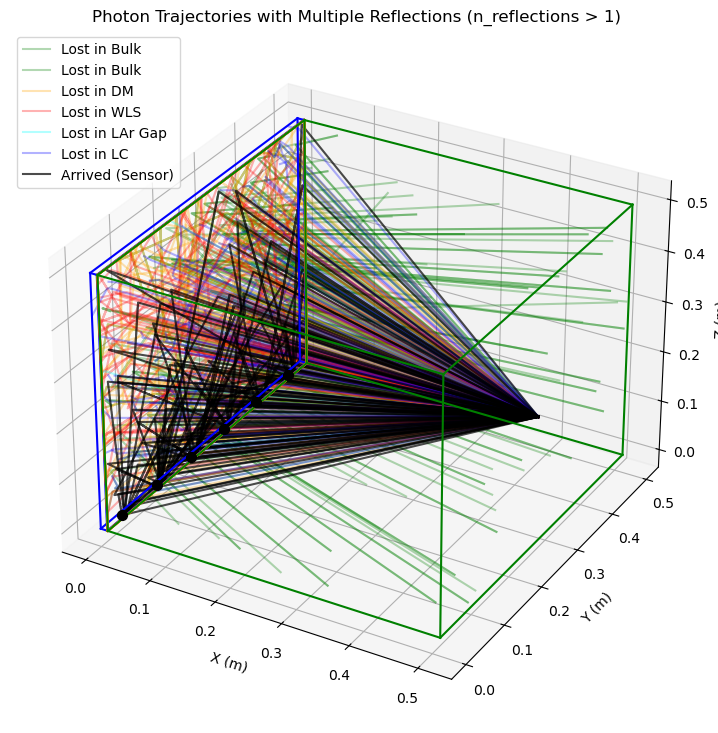

In [18]:
# Plot only trajectories with multiple reflections (n_reflections > 1)

plt.figure(figsize=(12, 9))
ax = plt.axes(projection='3d')
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')

def plot_trajectories(df_subset, color, label, alpha=0.3, max_lines=100):
  for i, traj_str in enumerate(df_subset['trajectory']):
    if i >= max_lines:
      break
    points = np.array([list(map(float, p.split(','))) for p in traj_str.split(';')], dtype=float)
    ax.plot(points[:,0], points[:,1], points[:,2], color=color, alpha=alpha, label=label if i == 0 else None)

df_multi_refl = df[df['n_reflections'] > 0]
plot_trajectories(df_multi_refl, 'green', 'Lost in Bulk')
plot_trajectories(df_multi_refl[df_multi_refl['event_type'] == 'lost_bulk'], 'green', 'Lost in Bulk')
plot_trajectories(df_multi_refl[df_multi_refl['event_type'] == 'lost_dm'], 'orange', 'Lost in DM')
plot_trajectories(df_multi_refl[df_multi_refl['event_type'] == 'lost_wls'], 'red', 'Lost in WLS')
plot_trajectories(df_multi_refl[df_multi_refl['event_type'] == 'lost_lar_gap'], 'cyan', 'Lost in LAr Gap')
plot_trajectories(df_multi_refl[df_multi_refl['event_type'] == 'lost_lc'], 'blue', 'Lost in LC')
plot_trajectories(df_multi_refl[df_multi_refl['event_type'] == 'arrived'], 'k', 'Arrived (Sensor)', alpha=0.7)

draw_box(lc_region_vertices, "blue")
draw_box(wls_region_vertices, "red")
draw_box(dm_region_vertices, "orange")
draw_box(bulk_region_vertices, "green")

for sp in sensor_positions:
  ax.scatter(sp[0], sp[1], sp[2], color="black", s=50)

ax.set_title('Photon Trajectories with Multiple Reflections (n_reflections > 1)')
ax.legend()
plt.show()


In [21]:
#print(df["event_type"].value_counts().head(30))

#print(df[df["n_reflections"] > 0]["event_type"].value_counts())

print(pd.crosstab(df["event_type"], df["n_reflections"]))


n_reflections         0     1     2     3     4     5     6     7     8     \
event_type                                                                   
absorbed_nonrad_lc       4     6     0     0     0     0     0     0     0   
absorbed_nonrad_wls    296     1    17     0     2     0     1     0     0   
arrived                 18     3     0     0     0     0     0     0     0   
lost_bulk            93449  2186     4    35     1     3     0     0     2   
lost_dm                  1     1     1     0     0     0     0     0     0   
lost_lar_gap             2     0     1     0     0     0     0     0     0   
lost_lc               1351   497    86    21     3     1     0     1     0   
lost_maxsteps_dm         0     0     0     0     0     0     0     0     0   
lost_maxsteps_wls        0     0     0     0     0     0     0     0     0   
lost_wls                 2     0     0     0     0     1     1     0     0   

n_reflections        9     ...  4881  4882  4883  4884  4885  4